This notebook accompanies the manuscript:

**A Performance-based Framework for Assessing Underground Hydrogen Storage Under Reservoir and Infrastructure Constraints: Application to Offshore Wind Curtailment Mitigation**



Worked example results: Anonymised reservoir

IPR/OPR intersection:
  Intersection BHP             = 167.149 bar
  Optimum deliverability rate  = 379,509.120 t H₂/month

Seasonal storage metrics:
  Plateau withdrawal rate      = 341,081.650 t H₂/month
  Final field-scale seasonal working capacity = 4,034,148.468 t H₂
  Final field-scale cushion gas = 5,926,148.927 t H₂
  Final field-scale C/W ratio  = 1.468996


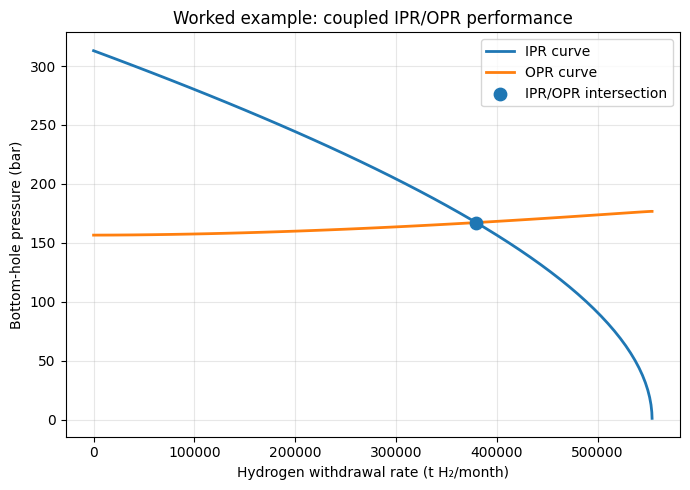

In [ ]:
"""
Worked example: analytical IPR/OPR calculation and seasonal working capacity
for one anonymised depleted gas reservoir. V1.0

Outputs:
- IPR/OPR intersection pressure
- Optimum deliverability rate
- Plateau withdrawal rate
- Final field-scale seasonal working capacity with minimum cushion-gas constraint
- Final cushion-to-working gas ratio, C/W
- IPR/OPR curve plot

Required package:
    pip install CoolProp
"""

# ============================================================
# 0. Import packages
# ============================================================

import sys
import subprocess
import importlib.util

def ensure_package(package_name: str):
    """Install a package if it is not already available."""
    if importlib.util.find_spec(package_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("CoolProp")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI


# ============================================================
# 1. USER INPUTS
# ============================================================

RESERVOIR_NAME = "Anonymised reservoir"

# -----------------------------
# Reservoir properties
# -----------------------------

RESERVOIR_PRESSURE_PA = 31_300_000        # maximum/average reservoir pressure, Pa
RESERVOIR_TEMPERATURE_K = 362.15          # reservoir temperature, K

PERMEABILITY_M2 = 2.17123126e-13          # permeability, m2
PERMEABILITY_MD = 220.0                   # permeability, mD
NET_THICKNESS_M = 40.5                    # net reservoir thickness, m

# -----------------------------
# Well and completion assumptions
# -----------------------------

DRAINAGE_RADIUS_M = 500.0                 # drainage radius, m
WELLBORE_RADIUS_M = 0.125                 # wellbore inner radius, m
SKIN = 0.0                                # mechanical skin factor

WELLBORE_ROUGHNESS_M = 0.000015           # wellbore roughness, m
WELLBORE_LENGTH_M = 625.7                 # wellbore length, m
WELLBORE_DEVIATION_ANGLE_DEG = 0.0        # deviation angle, degrees

# -----------------------------
# Surface condition
# -----------------------------

WELLHEAD_PRESSURE_PA = RESERVOIR_PRESSURE_PA / 2    # wellhead pressure, Pa

# -----------------------------
# IPR pressure schedule
# -----------------------------

MIN_BOTTOMHOLE_PRESSURE_PA = 101_325      # minimum bottom-hole pressure, Pa
PRESSURE_STEP_PA = 626_000                # pressure decrement, Pa

# -----------------------------
# Storage capacity inputs
# -----------------------------

OGIP_SM3 = 17_365_439_093.48442           # original gas in place, Sm3
RECOVERABLE_GAS_ESTIMATE_SM3 = 13_892_351_274.787539
NUMBER_OF_DEPLOYABLE_WELLBORES = 4        # deployable well count for field-scale estimates

WITHDRAWAL_PERIOD_DAYS = 90               # seasonal withdrawal period, days

# -----------------------------
# Density and conversion assumptions
# -----------------------------

H2_DENSITY_STD_KG_M3_FOR_RATE = 0.08988       # kg/m3, used for rate conversion
H2_DENSITY_STD_KG_M3_FOR_STORAGE = 0.08988    # kg/m3, used for storage mass conversion
METHANE_DENSITY_STD_KG_M3 = 0.656881734568035
HYDROGEN_DENSITY_STD_KG_M3 = 0.0823481221374309

DAYS_PER_MONTH = 30.4375
SECONDS_PER_DAY = 86_400
MW_H2_KG_MOL = 0.002016


# ============================================================
# 2. HYDROGEN PROPERTY FUNCTIONS
# ============================================================

def hydrogen_viscosity_pa_s(pressure_pa: float, temperature_k: float) -> float:
    """Hydrogen dynamic viscosity [Pa.s] from CoolProp."""
    return PropsSI("V", "P", pressure_pa, "T", temperature_k, "Hydrogen")


def hydrogen_z_factor(pressure_pa: float, temperature_k: float) -> float:
    """Hydrogen compressibility factor [-] from CoolProp."""
    density = PropsSI("D", "P", pressure_pa, "T", temperature_k, "Hydrogen")
    gas_constant = PropsSI("GAS_CONSTANT", "Hydrogen")
    r_specific = gas_constant / MW_H2_KG_MOL
    return pressure_pa / (density * r_specific * temperature_k)


# ============================================================
# 3. IPR FUNCTIONS
# ============================================================

def forchheimer_beta_jones(permeability_md: float) -> float:
    """Jones empirical Forchheimer inertial coefficient beta [1/m]."""
    return 2.017716535e11 / (permeability_md ** 1.55)


def pseudo_pressure_term(pressure_pa: float, viscosity_pa_s: float, z_factor: float) -> float:
    """
    Pseudo-pressure term used in this worked example:
        m(p) = p^2 / (mu * z)
    """
    return pressure_pa**2 / (viscosity_pa_s * z_factor)


def calculate_A_coefficient(
    temperature_k: float,
    permeability_m2: float,
    thickness_m: float,
    drainage_radius_m: float,
    wellbore_radius_m: float,
    skin: float,
) -> float:
    """Laminar flow coefficient A."""
    geometry_term = np.log(drainage_radius_m / wellbore_radius_m) - 0.75 + skin
    return 108.1762509 * (temperature_k / (permeability_m2 * thickness_m)) * geometry_term


def calculate_B_coefficient(
    beta_1_m: float,
    temperature_k: float,
    thickness_m: float,
    viscosity_pa_s: float,
    wellbore_radius_m: float,
) -> float:
    """Non-Darcy flow coefficient B."""
    return 0.0070372 * (beta_1_m * temperature_k * MW_H2_KG_MOL) / (
        thickness_m**2 * viscosity_pa_s * wellbore_radius_m
    )


def solve_quadratic_ipr_rate(delta_m: float, A: float, B: float) -> float:
    """
    Solve the quasi-quadratic IPR equation:
        delta_m = A q + B q^2

    Returns q [m3/s] at standard conditions.
    """
    if delta_m <= 0:
        return 0.0

    return (-A + np.sqrt(A**2 + 4 * B * delta_m)) / (2 * B)


def generate_pressure_schedule(
    reservoir_pressure_pa: float,
    min_pressure_pa: float,
    pressure_step_pa: float,
) -> np.ndarray:
    """Generate bottom-hole pressure values for the IPR curve."""
    pressures = []
    p = reservoir_pressure_pa

    while p > min_pressure_pa:
        pressures.append(p)
        p -= pressure_step_pa

    pressures.append(min_pressure_pa)
    return np.array(pressures)


def calculate_ipr_curve() -> pd.DataFrame:
    """Calculate the analytical IPR curve."""

    pressure_values_pa = generate_pressure_schedule(
        reservoir_pressure_pa=RESERVOIR_PRESSURE_PA,
        min_pressure_pa=MIN_BOTTOMHOLE_PRESSURE_PA,
        pressure_step_pa=PRESSURE_STEP_PA,
    )

    mu_res = hydrogen_viscosity_pa_s(RESERVOIR_PRESSURE_PA, RESERVOIR_TEMPERATURE_K)
    z_res = hydrogen_z_factor(RESERVOIR_PRESSURE_PA, RESERVOIR_TEMPERATURE_K)
    m_pr = pseudo_pressure_term(RESERVOIR_PRESSURE_PA, mu_res, z_res)

    beta = forchheimer_beta_jones(PERMEABILITY_MD)

    A = calculate_A_coefficient(
        temperature_k=RESERVOIR_TEMPERATURE_K,
        permeability_m2=PERMEABILITY_M2,
        thickness_m=NET_THICKNESS_M,
        drainage_radius_m=DRAINAGE_RADIUS_M,
        wellbore_radius_m=WELLBORE_RADIUS_M,
        skin=SKIN,
    )

    rows = []

    for p_bh in pressure_values_pa:
        mu_bh = hydrogen_viscosity_pa_s(p_bh, RESERVOIR_TEMPERATURE_K)
        z_bh = hydrogen_z_factor(p_bh, RESERVOIR_TEMPERATURE_K)

        m_pbh = pseudo_pressure_term(p_bh, mu_bh, z_bh)
        delta_m = m_pr - m_pbh

        B = calculate_B_coefficient(
            beta_1_m=beta,
            temperature_k=RESERVOIR_TEMPERATURE_K,
            thickness_m=NET_THICKNESS_M,
            viscosity_pa_s=mu_bh,
            wellbore_radius_m=WELLBORE_RADIUS_M,
        )

        q_m3_s = solve_quadratic_ipr_rate(delta_m, A, B)
        q_sm3_day = q_m3_s * SECONDS_PER_DAY
        q_t_month = q_sm3_day * H2_DENSITY_STD_KG_M3_FOR_RATE * DAYS_PER_MONTH / 1000.0

        rows.append(
            {
                "Q_m3_s": q_m3_s,
                "Q_Sm3_day": q_sm3_day,
                "Q_t_H2_month": q_t_month,
                "Pbh_IPR_Pa": p_bh,
                "Pbh_IPR_bar": p_bh / 1e5,
            }
        )

    return pd.DataFrame(rows)


# ============================================================
# 4. OPR FUNCTIONS
# ============================================================

def moody_friction_factor(reynolds_number: float, roughness_m: float, diameter_m: float) -> float:
    """Moody friction factor correlation used for OPR."""
    if reynolds_number <= 0:
        return np.nan

    term = (roughness_m / diameter_m) + (21.25 / (reynolds_number ** 0.9))
    return 4 * (2.28 - 4 * np.log10(term)) ** -2


def calculate_opr_curve(ipr_df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the OPR curve using the IPR flow-rate grid."""

    diameter_m = 2 * WELLBORE_RADIUS_M
    average_temperature_k = (RESERVOIR_TEMPERATURE_K + 278.15) / 2

    reynolds_constant = 0.0150767
    flow_conversion_factor = 0.06961
    gravity_constant_opr = 0.0006836286
    friction_pressure_constant = 93616.81014

    theta_rad = np.deg2rad(WELLBORE_DEVIATION_ANGLE_DEG)
    cos_theta = np.cos(theta_rad)

    rows = []

    for _, row in ipr_df.iterrows():
        q_m3_s = row["Q_m3_s"]
        p_reference_pa = row["Pbh_IPR_Pa"]

        p_average_pa = (WELLHEAD_PRESSURE_PA + p_reference_pa) / 2
        z_average = hydrogen_z_factor(p_average_pa, average_temperature_k)
        mu_average = hydrogen_viscosity_pa_s(p_average_pa, average_temperature_k)

        reynolds_number = reynolds_constant * (
            (flow_conversion_factor * q_m3_s) / (diameter_m * mu_average)
        )

        friction_factor = moody_friction_factor(
            reynolds_number=reynolds_number,
            roughness_m=WELLBORE_ROUGHNESS_M,
            diameter_m=diameter_m,
        )

        s_factor = gravity_constant_opr * (
            (flow_conversion_factor * WELLBORE_LENGTH_M * cos_theta)
            / (z_average * average_temperature_k)
        )

        if q_m3_s == 0:
            p_bh_opr_pa = WELLHEAD_PRESSURE_PA
        else:
            p_bh_opr_pa = np.sqrt(
                (np.exp(s_factor) * WELLHEAD_PRESSURE_PA**2)
                + (
                    friction_pressure_constant
                    * friction_factor
                    * q_m3_s**2
                    * z_average**2
                    * average_temperature_k**2
                    * (np.exp(s_factor) - 1)
                )
                / ((diameter_m**5) * cos_theta)
            )

        rows.append(
            {
                "Q_m3_s": q_m3_s,
                "Q_Sm3_day": row["Q_Sm3_day"],
                "Q_t_H2_month": row["Q_t_H2_month"],
                "Pbh_OPR_Pa": p_bh_opr_pa,
                "Pbh_OPR_bar": p_bh_opr_pa / 1e5,
            }
        )

    return pd.DataFrame(rows)


# ============================================================
# 5. IPR/OPR INTERSECTION
# ============================================================

def find_ipr_opr_intersection(ipr_df: pd.DataFrame, opr_df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Find the IPR/OPR intersection using sign change and linear interpolation."""

    coupled_df = pd.DataFrame(
        {
            "Q_m3_s": ipr_df["Q_m3_s"],
            "Q_Sm3_day": ipr_df["Q_Sm3_day"],
            "Q_t_H2_month": ipr_df["Q_t_H2_month"],
            "Pbh_IPR_bar": ipr_df["Pbh_IPR_bar"],
            "Pbh_OPR_bar": opr_df["Pbh_OPR_bar"],
        }
    )

    coupled_df["pressure_difference_bar"] = (
        coupled_df["Pbh_IPR_bar"] - coupled_df["Pbh_OPR_bar"]
    )

    sign_change_indices = np.where(
        np.sign(coupled_df["pressure_difference_bar"].values[:-1])
        != np.sign(coupled_df["pressure_difference_bar"].values[1:])
    )[0]

    if len(sign_change_indices) == 0:
        raise ValueError(
            "No IPR/OPR intersection found. "
            "Check pressure range, wellhead pressure, or model inputs."
        )

    idx = sign_change_indices[0]

    x1 = coupled_df.loc[idx, "Q_m3_s"]
    x2 = coupled_df.loc[idx + 1, "Q_m3_s"]
    y1 = coupled_df.loc[idx, "pressure_difference_bar"]
    y2 = coupled_df.loc[idx + 1, "pressure_difference_bar"]

    q_intersection_m3_s = x1 - y1 * (x2 - x1) / (y2 - y1)

    intersection = {
        "Q_m3_s": q_intersection_m3_s,
        "Q_Sm3_day": np.interp(q_intersection_m3_s, coupled_df["Q_m3_s"], coupled_df["Q_Sm3_day"]),
        "Q_t_H2_month": np.interp(q_intersection_m3_s, coupled_df["Q_m3_s"], coupled_df["Q_t_H2_month"]),
        "Pbh_bar": np.interp(q_intersection_m3_s, coupled_df["Q_m3_s"], coupled_df["Pbh_IPR_bar"]),
    }

    return coupled_df, intersection


# ============================================================
# 6. PLATEAU RATE, WORKING GAS, AND CUSHION GAS
# ============================================================

def calculate_storage_capacity_metrics(intersection: dict) -> dict:
    """
    Calculate plateau rate, field-scale seasonal working capacity,
    cushion gas, and final C/W ratio with minimum cushion-gas constraint.
    """

    q_max_sm3_day = intersection["Q_Sm3_day"]

    equivalent_h2_in_place_sm3 = (
        METHANE_DENSITY_STD_KG_M3
        * RECOVERABLE_GAS_ESTIMATE_SM3
        / HYDROGEN_DENSITY_STD_KG_M3
    )

    equivalent_h2_in_place_tonnes = (
        equivalent_h2_in_place_sm3
        * H2_DENSITY_STD_KG_M3_FOR_STORAGE
        / 1000.0
    )

    q_plateau_sm3_day = 1.0 / (
        (1.0 / q_max_sm3_day)
        + (WITHDRAWAL_PERIOD_DAYS / equivalent_h2_in_place_sm3)
    )

    q_plateau_t_month = (
        q_plateau_sm3_day
        * H2_DENSITY_STD_KG_M3_FOR_RATE
        * DAYS_PER_MONTH
        / 1000.0
    )

    seasonal_working_capacity_per_well_tonnes = (
        q_plateau_sm3_day
        * WITHDRAWAL_PERIOD_DAYS
        * H2_DENSITY_STD_KG_M3_FOR_STORAGE
        / 1000.0
    )

    unconstrained_field_working_capacity_tonnes = (
        seasonal_working_capacity_per_well_tonnes
        * NUMBER_OF_DEPLOYABLE_WELLBORES
    )

    unconstrained_field_cushion_gas_tonnes = (
        equivalent_h2_in_place_tonnes
        - unconstrained_field_working_capacity_tonnes
    )

    if unconstrained_field_cushion_gas_tonnes < unconstrained_field_working_capacity_tonnes:
        final_field_working_capacity_tonnes = equivalent_h2_in_place_tonnes / 2.0
    else:
        final_field_working_capacity_tonnes = unconstrained_field_working_capacity_tonnes

    final_field_cushion_gas_tonnes = (
        equivalent_h2_in_place_tonnes
        - final_field_working_capacity_tonnes
    )

    final_cw_ratio = final_field_cushion_gas_tonnes / final_field_working_capacity_tonnes

    return {
        "q_plateau_sm3_day": q_plateau_sm3_day,
        "q_plateau_t_month": q_plateau_t_month,
        "final_field_working_capacity_tonnes": final_field_working_capacity_tonnes,
        "final_field_cushion_gas_tonnes": final_field_cushion_gas_tonnes,
        "final_cw_ratio": final_cw_ratio,
    }


# ============================================================
# 7. PLOT
# ============================================================

def plot_ipr_opr(coupled_df: pd.DataFrame, intersection: dict) -> None:
    """Plot IPR and OPR curves with the intersection point."""

    plt.figure(figsize=(7, 5))

    plt.plot(
        coupled_df["Q_t_H2_month"],
        coupled_df["Pbh_IPR_bar"],
        linewidth=2,
        label="IPR curve",
    )

    plt.plot(
        coupled_df["Q_t_H2_month"],
        coupled_df["Pbh_OPR_bar"],
        linewidth=2,
        label="OPR curve",
    )

    plt.scatter(
        intersection["Q_t_H2_month"],
        intersection["Pbh_bar"],
        s=80,
        zorder=5,
        label="IPR/OPR intersection",
    )

    plt.xlabel("Hydrogen withdrawal rate (t H₂/month)")
    plt.ylabel("Bottom-hole pressure (bar)")
    plt.title("Worked example: coupled IPR/OPR performance")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 8. MAIN RUN
# ============================================================

def main():
    ipr_df = calculate_ipr_curve()
    opr_df = calculate_opr_curve(ipr_df)

    coupled_df, intersection = find_ipr_opr_intersection(ipr_df, opr_df)
    storage_metrics = calculate_storage_capacity_metrics(intersection)

    print("\n============================================================")
    print(f"Worked example results: {RESERVOIR_NAME}")
    print("============================================================")

    print("\nIPR/OPR intersection:")
    print(f"  Intersection BHP             = {intersection['Pbh_bar']:,.3f} bar")
    print(f"  Optimum deliverability rate  = {intersection['Q_t_H2_month']:,.3f} t H₂/month")

    print("\nSeasonal storage metrics:")
    print(f"  Plateau withdrawal rate      = {storage_metrics['q_plateau_t_month']:,.3f} t H₂/month")
    print(
        "  Final field-scale seasonal working capacity "
        f"= {storage_metrics['final_field_working_capacity_tonnes']:,.3f} t H₂"
    )
    print(
        "  Final field-scale cushion gas "
        f"= {storage_metrics['final_field_cushion_gas_tonnes']:,.3f} t H₂"
    )
    print(f"  Final field-scale C/W ratio  = {storage_metrics['final_cw_ratio']:,.6f}")

    plot_ipr_opr(coupled_df, intersection)

    return coupled_df, intersection, storage_metrics


if __name__ == "__main__":
    coupled_df, intersection, storage_metrics = main()


Worked example injectivity results: Anonymised reservoir

Injection pressure assumptions:
  Maximum allowable injection BHP = 313.000 bar
  Minimum reservoir pressure = 156.500 bar

Injectivity result:
  Maximum theoretical wellbore-level injectivity = 400,004.224 t H₂/month
  Injection BHP at maximum injectivity = 313.000 bar
  Reservoir pressure at maximum injectivity = 156.500 bar


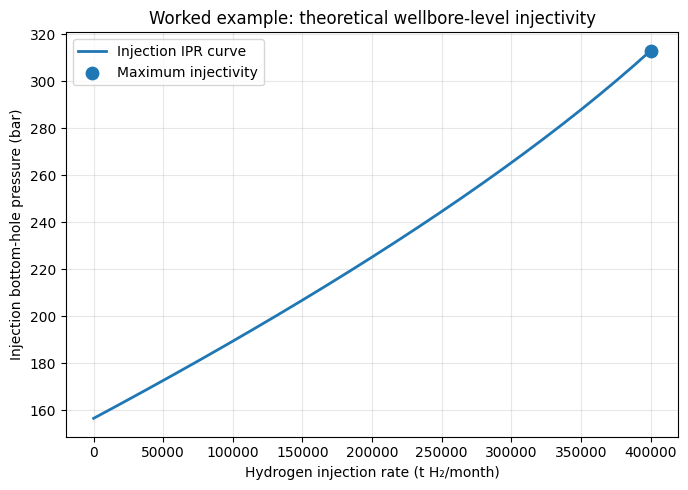

In [ ]:
"""
Worked example: theoretical wellbore-level hydrogen injectivity calculation
for one anonymised depleted gas reservoir. V1.0

This script calculates the injection IPR curve and reports the maximum
theoretical wellbore-level injectivity.

The curve construction follows the screening workflow:
    - Maximum allowable injection bottom-hole pressure is set to Pi.
    - Minimum reservoir pressure after withdrawal is set to Pi/2.
    - Injection BHP is plotted from Pi down to Pi/2.
    - The corresponding reservoir pressure moves from Pi/2 up to Pi.
    - The pseudo-pressure driving force is calculated as:
          delta_m = m(Pi) - m(P_res)

Output:
    - Maximum theoretical wellbore-level injectivity (t H2/month)
    - Injection IPR curve

Required package:
    pip install CoolProp
"""

# ============================================================
# 0. Import packages
# ============================================================

import sys
import subprocess
import importlib.util

def ensure_package(package_name: str):
    """Install a package if it is not already available."""
    if importlib.util.find_spec(package_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("CoolProp")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI


# ============================================================
# 1. USER INPUTS
# ============================================================

RESERVOIR_NAME = "Anonymised reservoir"

# -----------------------------
# Reservoir properties
# -----------------------------

INITIAL_RESERVOIR_PRESSURE_PA = 31_300_000       # Maximum reservoir pressure, Pa
RESERVOIR_TEMPERATURE_K = 362.15                 # reservoir temperature, K

PERMEABILITY_M2 = 2.17123126e-13                 # permeability, m2
PERMEABILITY_MD = 220.0                          # permeability, mD
NET_THICKNESS_M = 40.5                           # net reservoir thickness, m

# -----------------------------
# Well and completion assumptions
# -----------------------------

DRAINAGE_RADIUS_M = 500.0                        # drainage radius, m
WELLBORE_RADIUS_M = 0.125                        # wellbore inner radius, m
SKIN = 0.0                                       # mechanical skin factor

# -----------------------------
# Injection pressure window
# -----------------------------

MAX_INJECTION_BOTTOMHOLE_PRESSURE_PA = INITIAL_RESERVOIR_PRESSURE_PA
MIN_RESERVOIR_PRESSURE_PA = INITIAL_RESERVOIR_PRESSURE_PA / 2

PRESSURE_STEP_PA = 626_000                       # pressure decrement, Pa

# -----------------------------
# Density and conversion assumptions
# -----------------------------

H2_DENSITY_STD_KG_M3 = 0.08988                   # kg/m3
DAYS_PER_MONTH = 30.4375
SECONDS_PER_DAY = 86_400
MW_H2_KG_MOL = 0.002016                          # kg/mol


# ============================================================
# 2. HYDROGEN PROPERTY FUNCTIONS
# ============================================================

def hydrogen_viscosity_pa_s(pressure_pa: float, temperature_k: float) -> float:
    """Hydrogen dynamic viscosity [Pa.s] from CoolProp."""
    return PropsSI("V", "P", pressure_pa, "T", temperature_k, "Hydrogen")


def hydrogen_z_factor(pressure_pa: float, temperature_k: float) -> float:
    """Hydrogen compressibility factor [-] from CoolProp."""
    density = PropsSI("D", "P", pressure_pa, "T", temperature_k, "Hydrogen")
    gas_constant = PropsSI("GAS_CONSTANT", "Hydrogen")
    r_specific = gas_constant / MW_H2_KG_MOL
    return pressure_pa / (density * r_specific * temperature_k)


# ============================================================
# 3. INJECTION IPR FUNCTIONS
# ============================================================

def forchheimer_beta_jones(permeability_md: float) -> float:
    """Jones empirical Forchheimer inertial coefficient beta [1/m]."""
    return 2.017716535e11 / (permeability_md ** 1.55)


def pseudo_pressure_term(
    pressure_pa: float,
    viscosity_pa_s: float,
    z_factor: float,
) -> float:
    """
    Pseudo-pressure term used in this worked example:
        m(p) = p^2 / (mu * z)
    """
    return pressure_pa**2 / (viscosity_pa_s * z_factor)


def calculate_A_coefficient(
    temperature_k: float,
    permeability_m2: float,
    thickness_m: float,
    drainage_radius_m: float,
    wellbore_radius_m: float,
    skin: float,
) -> float:
    """Laminar flow coefficient A."""
    geometry_term = np.log(drainage_radius_m / wellbore_radius_m) - 0.75 + skin
    return 108.1762509 * (temperature_k / (permeability_m2 * thickness_m)) * geometry_term


def calculate_B_coefficient(
    beta_1_m: float,
    temperature_k: float,
    thickness_m: float,
    viscosity_pa_s: float,
    wellbore_radius_m: float,
) -> float:
    """Non-Darcy flow coefficient B."""
    return 0.0070372 * (beta_1_m * temperature_k * MW_H2_KG_MOL) / (
        thickness_m**2 * viscosity_pa_s * wellbore_radius_m
    )


def solve_quadratic_ipr_rate(delta_m: float, A: float, B: float) -> float:
    """
    Solve the quasi-quadratic IPR equation:
        delta_m = A q + B q^2

    Returns q [m3/s] at standard conditions.
    """
    if delta_m <= 0:
        return 0.0

    return (-A + np.sqrt(A**2 + 4 * B * delta_m)) / (2 * B)


def generate_injection_pressure_schedules(
    initial_pressure_pa: float,
    minimum_reservoir_pressure_pa: float,
    pressure_step_pa: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate paired pressure schedules for injection IPR.

    The injection bottom-hole pressure decreases from Pi to Pi/2.
    The corresponding reservoir pressure increases from Pi/2 to Pi.

    This produces the injection curve direction used in the spreadsheet:
        P_bh,inj: Pi   -> Pi/2
        P_res:    Pi/2 -> Pi
    """

    injection_bhp_values = []
    p_bh = initial_pressure_pa

    while p_bh > minimum_reservoir_pressure_pa:
        injection_bhp_values.append(p_bh)
        p_bh -= pressure_step_pa

    injection_bhp_values.append(minimum_reservoir_pressure_pa)
    injection_bhp_values = np.array(injection_bhp_values)

    reservoir_pressure_values = (
        initial_pressure_pa + minimum_reservoir_pressure_pa - injection_bhp_values
    )

    return injection_bhp_values, reservoir_pressure_values


def calculate_injection_ipr_curve() -> pd.DataFrame:
    """
    Calculate the injection IPR curve.

    For injection:
        delta_m = m(Pi) - m(P_res)

    where:
        Pi is the maximum allowable injection pressure,
        P_res varies from Pi/2 to Pi,
        and the plotted injection BHP varies from Pi to Pi/2.
    """

    injection_bhp_values_pa, reservoir_pressure_values_pa = generate_injection_pressure_schedules(
        initial_pressure_pa=INITIAL_RESERVOIR_PRESSURE_PA,
        minimum_reservoir_pressure_pa=MIN_RESERVOIR_PRESSURE_PA,
        pressure_step_pa=PRESSURE_STEP_PA,
    )

    # Fixed pseudo-pressure term at maximum allowable pressure, Pi
    mu_pi = hydrogen_viscosity_pa_s(
        INITIAL_RESERVOIR_PRESSURE_PA,
        RESERVOIR_TEMPERATURE_K,
    )
    z_pi = hydrogen_z_factor(
        INITIAL_RESERVOIR_PRESSURE_PA,
        RESERVOIR_TEMPERATURE_K,
    )

    m_pi = pseudo_pressure_term(
        INITIAL_RESERVOIR_PRESSURE_PA,
        mu_pi,
        z_pi,
    )

    beta = forchheimer_beta_jones(PERMEABILITY_MD)

    A = calculate_A_coefficient(
        temperature_k=RESERVOIR_TEMPERATURE_K,
        permeability_m2=PERMEABILITY_M2,
        thickness_m=NET_THICKNESS_M,
        drainage_radius_m=DRAINAGE_RADIUS_M,
        wellbore_radius_m=WELLBORE_RADIUS_M,
        skin=SKIN,
    )

    rows = []

    for p_bh_inj, p_res in zip(injection_bhp_values_pa, reservoir_pressure_values_pa):

        # B is evaluated at the injection bottom-hole pressure for this point
        mu_bh = hydrogen_viscosity_pa_s(p_bh_inj, RESERVOIR_TEMPERATURE_K)

        B = calculate_B_coefficient(
            beta_1_m=beta,
            temperature_k=RESERVOIR_TEMPERATURE_K,
            thickness_m=NET_THICKNESS_M,
            viscosity_pa_s=mu_bh,
            wellbore_radius_m=WELLBORE_RADIUS_M,
        )

        # Reservoir pseudo-pressure term
        mu_res = hydrogen_viscosity_pa_s(p_res, RESERVOIR_TEMPERATURE_K)
        z_res = hydrogen_z_factor(p_res, RESERVOIR_TEMPERATURE_K)

        m_res = pseudo_pressure_term(
            p_res,
            mu_res,
            z_res,
        )

        delta_m = m_pi - m_res

        q_m3_s = solve_quadratic_ipr_rate(
            delta_m=delta_m,
            A=A,
            B=B,
        )

        q_sm3_day = q_m3_s * SECONDS_PER_DAY
        q_t_month = q_sm3_day * H2_DENSITY_STD_KG_M3 * DAYS_PER_MONTH / 1000.0

        rows.append(
            {
                "Injection_BHP_Pa": p_bh_inj,
                "Injection_BHP_bar": p_bh_inj / 1e5,
                "Reservoir_pressure_Pa": p_res,
                "Reservoir_pressure_bar": p_res / 1e5,
                "Q_m3_s": q_m3_s,
                "Q_t_H2_month": q_t_month,
            }
        )

    return pd.DataFrame(rows)


# ============================================================
# 4. MAXIMUM THEORETICAL WELLBORE-LEVEL INJECTIVITY
# ============================================================

def calculate_maximum_injectivity(injection_df: pd.DataFrame) -> dict:
    """
    Extract maximum theoretical wellbore-level injectivity.
    """

    idx = injection_df["Q_t_H2_month"].idxmax()
    row = injection_df.loc[idx]

    return {
        "Injection_BHP_bar_at_max_injectivity": row["Injection_BHP_bar"],
        "Reservoir_pressure_bar_at_max_injectivity": row["Reservoir_pressure_bar"],
        "Maximum_theoretical_wellbore_level_injectivity_t_H2_month": row["Q_t_H2_month"],
    }


# ============================================================
# 5. PLOT
# ============================================================

def plot_injection_ipr(
    injection_df: pd.DataFrame,
    max_result: dict,
) -> None:
    """
    Plot injection IPR curve.

    The plotted pressure is injection bottom-hole pressure.
    The curve direction follows the spreadsheet:
        high rate at high injection BHP,
        zero rate at lower injection BHP.
    """

    plt.figure(figsize=(7, 5))

    plt.plot(
        injection_df["Q_t_H2_month"],
        injection_df["Injection_BHP_bar"],
        linewidth=2,
        label="Injection IPR curve",
    )

    plt.scatter(
        max_result["Maximum_theoretical_wellbore_level_injectivity_t_H2_month"],
        max_result["Injection_BHP_bar_at_max_injectivity"],
        s=80,
        zorder=5,
        label="Maximum injectivity",
    )

    plt.xlabel("Hydrogen injection rate (t H₂/month)")
    plt.ylabel("Injection bottom-hole pressure (bar)")
    plt.title("Worked example: theoretical wellbore-level injectivity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. MAIN RUN
# ============================================================

def main():
    injection_df = calculate_injection_ipr_curve()
    max_result = calculate_maximum_injectivity(injection_df)

    print("\n============================================================")
    print(f"Worked example injectivity results: {RESERVOIR_NAME}")
    print("============================================================")

    print("\nInjection pressure assumptions:")
    print(
        "  Maximum allowable injection BHP "
        f"= {MAX_INJECTION_BOTTOMHOLE_PRESSURE_PA / 1e5:,.3f} bar"
    )
    print(
        "  Minimum reservoir pressure "
        f"= {MIN_RESERVOIR_PRESSURE_PA / 1e5:,.3f} bar"
    )

    print("\nInjectivity result:")
    print(
        "  Maximum theoretical wellbore-level injectivity "
        f"= {max_result['Maximum_theoretical_wellbore_level_injectivity_t_H2_month']:,.3f} t H₂/month"
    )
    print(
        "  Injection BHP at maximum injectivity "
        f"= {max_result['Injection_BHP_bar_at_max_injectivity']:,.3f} bar"
    )
    print(
        "  Reservoir pressure at maximum injectivity "
        f"= {max_result['Reservoir_pressure_bar_at_max_injectivity']:,.3f} bar"
    )

    plot_injection_ipr(injection_df, max_result)

    return injection_df, max_result


if __name__ == "__main__":
    injection_df, max_result = main()